# 🔫 2D CNN Gunshot Detector — Mel Spectrogram / MFCC Classification

A **complete pipeline** that classifies 250ms audio clips as **gunshot** or **non-gunshot** using a 2D CNN operating on Mel Spectrograms or MFCCs.

## Why 2D CNN?
- **Research consensus (2024-2025)**: 2D CNN + Mel Spectrogram is the gold standard for audio classification
- Treats audio as a **2D image** (frequency × time) — CNNs are designed for this
- Gunshots appear as **vertical stripes** (all frequencies explode simultaneously)
- Background noise appears as **horizontal bars** (constant frequency hum)
- Achieves **94%+ accuracy** in published research

## Feature Options
| Feature | Best For |
|---------|----------|
| `mel_spectrogram` | Maximum accuracy (keeps all spectral detail) |
| `mfcc` | Smallest model (13 rows vs 64 — fits on Arduino) |

## How To Use
1. Set `DATA_DIR` in Cell 3
2. Choose `FEATURE_TYPE`: `mel_spectrogram` or `mfcc`
3. Run all cells

See `manual/README.md` for complete theory.

In [ ]:
# ============================================================
# CELL 1: Install Dependencies
# ============================================================
%pip install -q tensorflow librosa soundfile scikit-learn matplotlib seaborn tqdm pandas numpy

In [ ]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
import re
import json
import random
from pathlib import Path
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import librosa
import librosa.display

import tensorflow as tf
import keras
from keras import layers, models, callbacks
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    fbeta_score,
    roc_curve,
    precision_recall_curve
)

# ============================================================
# CELL 3: CONFIGURATION
# ============================================================
# DATA PATH — Dynamic workspace path resolution
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name in ['01_1D_CNN', '02_2D_CNN', '03_Mic_Test', '04_Robust_CRNN_PCEN']:
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / 'Data' / 'SPLIT_DATASET_750MS'

# FEATURE TYPE — Choose what the CNN "sees"
FEATURE_TYPE = 'mel_spectrogram'   # Options: 'mel_spectrogram' or 'mfcc'

# SAMPLE RATE
SAMPLE_RATE = 22050       # Native quality

# FEATURE EXTRACTION PARAMETERS
N_MELS = 64               # Mel filterbank size (64 for mel_spectrogram)
N_MFCC = 13               # MFCC coefficients (13 for mfcc)
N_FFT = 512               # FFT window size
HOP_LENGTH = 128          # Hop between FFT windows

# AUDIO PARAMETERS
CLIP_DURATION_MS = 750
TARGET_SAMPLES = int(SAMPLE_RATE * CLIP_DURATION_MS / 1000)

# TRAINING PARAMETERS
BATCH_SIZE = 64
EPOCHS = 50
LEARNING_RATE = 0.001
TEST_SPLIT = 0.15
VALIDATION_SPLIT = 0.15

# AUGMENTATION
USE_AUGMENTATION = True
USE_ONLY_CLEAN = True
SHUFFLE_DATA = True

# SpecAugment parameters
FREQ_MASK_PARAM = 8       # Max frequency bins to mask
TIME_MASK_PARAM = 8       # Max time steps to mask

# OUTPUT
OUTPUT_DIR = PROJECT_ROOT / '02_2D_CNN' / 'output'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Print config ---
print(f'\n{"=" * 60}')
print(f'2D CNN GUNSHOT DETECTOR — CONFIGURATION')
print(f'{"=" * 60}')
print(f'Feature Type     : {FEATURE_TYPE}')
print(f'Data Directory   : {DATA_DIR}')
print(f'Sample Rate      : {SAMPLE_RATE:,} Hz')
print(f'N_MELS / N_MFCC  : {N_MELS} / {N_MFCC}')
print(f'N_FFT            : {N_FFT}')
print(f'Hop Length       : {HOP_LENGTH}')
print(f'Clip Duration    : {CLIP_DURATION_MS}ms ({TARGET_SAMPLES:,} samples)')
print(f'SpecAugment      : freq_mask={FREQ_MASK_PARAM}, time_mask={TIME_MASK_PARAM}')
print(f'Output           : {OUTPUT_DIR}')
print(f'{"=" * 60}')
print("GPUs Available:", tf.config.list_physical_devices('GPU'))

c:\Users\aadit\.conda\envs\Shooter_model\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



2D CNN GUNSHOT DETECTOR — CONFIGURATION
Feature Type     : mel_spectrogram
Data Directory   : C:\Users\aadit\Desktop\Shoot_Catcher\Data\SPLIT_DATASET_750MS
Sample Rate      : 22,050 Hz
N_MELS / N_MFCC  : 64 / 13
N_FFT            : 512
Hop Length       : 128
Clip Duration    : 750ms (16,537 samples)
SpecAugment      : freq_mask=8, time_mask=8
Output           : C:\Users\aadit\Desktop\Shoot_Catcher\02_2D_CNN\output
GPUs Available: []


In [2]:
# ============================================================
# CELL 4: Data Loading & GroupKFold Splitting
# ============================================================
import os
import re
import random
import numpy as np
from pathlib import Path

# Ensure DATA_DIR and configuration variables exist
if 'DATA_DIR' not in globals() or not Path(DATA_DIR).exists():
    PROJECT_ROOT = Path.cwd().resolve()
    if PROJECT_ROOT.name in ['01_1D_CNN', '02_2D_CNN', '03_Mic_Test', '04_Robust_CRNN_PCEN']:
        PROJECT_ROOT = PROJECT_ROOT.parent
    DATA_DIR = PROJECT_ROOT / 'Data' / 'SPLIT_DATASET_750MS'

if 'USE_ONLY_CLEAN' not in globals():
    USE_ONLY_CLEAN = True
if 'SHUFFLE_DATA' not in globals():
    SHUFFLE_DATA = True
if 'TEST_SPLIT' not in globals():
    TEST_SPLIT = 0.15
if 'VALIDATION_SPLIT' not in globals():
    VALIDATION_SPLIT = 0.15

def extract_source_group(filename):
    stem = Path(filename).stem
    no_prefix = re.sub(r'^c[01]_\d+_', '', stem)
    no_suffix = re.sub(r'_clip\d+.*$', '', no_prefix)
    no_aug = re.sub(r'_aug_\d+dB$', '', no_suffix)
    return no_aug if no_aug else stem

def is_clean_file(filename):
    return '_aug_' not in Path(filename).stem

def collect_audio_files(data_dir, use_only_clean=True):
    data_dir = Path(data_dir)
    files, labels, groups = [], [], []
    
    subdirs = []
    split_folders = [d for d in data_dir.iterdir() if d.is_dir() and d.name.lower() in ['train', 'val', 'test', 'split']]
    if split_folders:
        for split in split_folders:
            subdirs.extend([d for d in split.iterdir() if d.is_dir()])
    else:
        subdirs = [d for d in data_dir.iterdir() if d.is_dir()]
    
    class_map = {}
    for d in subdirs:
        name = d.name.lower()
        if 'class_0' in name or 'nongunshot' in name or 'background' in name or 'noise' in name:
            class_map[d] = 0
        elif 'class_1' in name or 'gunshot' in name or 'gun' in name:
            class_map[d] = 1
    
    if not class_map:
        raise ValueError(f'Could not auto-detect class folders in {data_dir}')
    
    for folder, label in class_map.items():
        for f in sorted(folder.glob('*.wav')):
            if use_only_clean and not is_clean_file(f.name):
                continue
            files.append(str(f))
            labels.append(label)
            groups.append(extract_source_group(f.name))
    
    return files, labels, groups

# --- Load & shuffle ---
print(f'📂 Loading data from: {DATA_DIR}\n')
all_files, all_labels, all_groups = collect_audio_files(DATA_DIR, USE_ONLY_CLEAN)

if SHUFFLE_DATA:
    combined = list(zip(all_files, all_labels, all_groups))
    random.shuffle(combined)
    all_files, all_labels, all_groups = zip(*combined)
    all_files, all_labels, all_groups = list(all_files), list(all_labels), list(all_groups)

# --- GroupKFold split ---
unique_groups = list(set(all_groups))
random.shuffle(unique_groups)
n_test = max(1, int(len(unique_groups) * TEST_SPLIT))
test_groups = set(unique_groups[:n_test])

train_val_f, train_val_l, train_val_g = [], [], []
test_f, test_l = [], []

for f, l, g in zip(all_files, all_labels, all_groups):
    if g in test_groups:
        test_f.append(f); test_l.append(l)
    else:
        train_val_f.append(f); train_val_l.append(l); train_val_g.append(g)

tv_groups = list(set(train_val_g))
random.shuffle(tv_groups)
n_val = max(1, int(len(tv_groups) * (VALIDATION_SPLIT / (1 - TEST_SPLIT))))
val_groups_set = set(tv_groups[:n_val])

train_f, train_l, val_f, val_l = [], [], [], []
for f, l, g in zip(train_val_f, train_val_l, train_val_g):
    if g in val_groups_set:
        val_f.append(f); val_l.append(l)
    else:
        train_f.append(f); train_l.append(l)

# Option C: add augmented to training only
if USE_ONLY_CLEAN:
    train_groups_set = set(extract_source_group(Path(f).name) for f in train_f)
    search_folders = []
    split_folders = [d for d in DATA_DIR.iterdir() if d.is_dir() and d.name.lower() in ['train', 'val', 'test', 'split']]
    if split_folders:
        for split in split_folders:
            search_folders.extend([d for d in split.iterdir() if d.is_dir()])
    else:
        search_folders = [d for d in DATA_DIR.iterdir() if d.is_dir()]
    for d in search_folders:
        name = d.name.lower()
        label = 1 if ('class_1' in name or 'gunshot' in name) else 0 if ('class_0' in name or 'nongunshot' in name) else -1
        if label < 0: continue
        for f in d.glob('*.wav'):
            if not is_clean_file(f.name) and extract_source_group(f.name) in train_groups_set:
                train_f.append(str(f)); train_l.append(label)
    combined = list(zip(train_f, train_l))
    random.shuffle(combined)
    train_f, train_l = zip(*combined)
    train_f, train_l = list(train_f), list(train_l)

# Print summary
for name, files, lbls in [('TRAIN', train_f, train_l), ('VAL', val_f, val_l), ('TEST', test_f, test_l)]:
    arr = np.array(lbls)
    print(f'{name:5s}: {len(files):>6,} files | 🔫 {int(np.sum(arr==1)):>5,} | 🎵 {int(np.sum(arr==0)):>5,}')

📂 Loading data from: C:\Users\aadit\Desktop\Shoot_Catcher\Data\SPLIT_DATASET_750MS

TRAIN: 31,249 files | 🔫 3,195 | 🎵 28,054
VAL  :  6,696 files | 🔫   651 | 🎵 6,045
TEST :  6,696 files | 🔫   654 | 🎵 6,042


C:\Users\aadit\AppData\Local\Temp\ipykernel_8480\3572747581.py:65: UserWarning: Glyph 128299 (\N{PISTOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\aadit\AppData\Local\Temp\ipykernel_8480\3572747581.py:65: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\aadit\AppData\Local\Temp\ipykernel_8480\3572747581.py:66: UserWarning: Glyph 128299 (\N{PISTOL}) missing from font(s) DejaVu Sans.
  plt.savefig(OUTPUT_DIR / 'feature_comparison.png', dpi=150)
C:\Users\aadit\AppData\Local\Temp\ipykernel_8480\3572747581.py:66: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  plt.savefig(OUTPUT_DIR / 'feature_comparison.png', dpi=150)
c:\Users\aadit\.conda\envs\Shooter_model\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128299 (\N{PISTOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\aadit\.conda\envs\Shooter_model\lib\site-packag

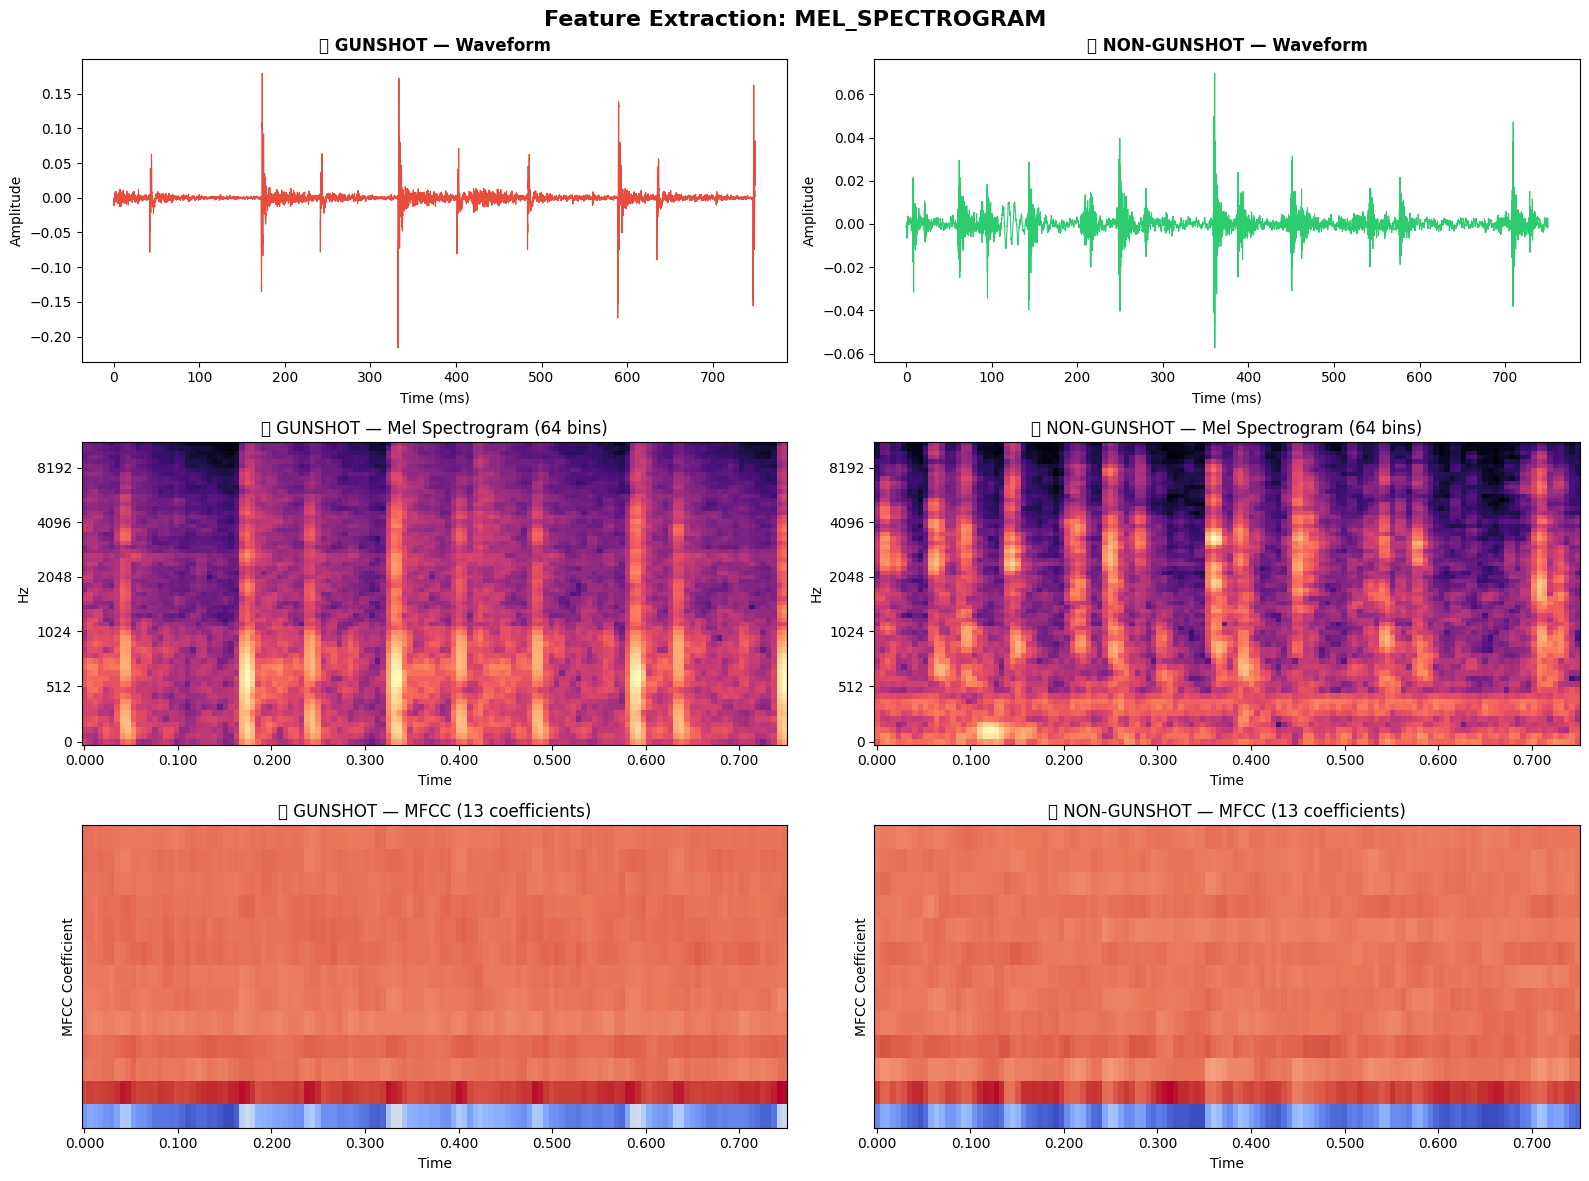


📐 Feature shape for mel_spectrogram: (64, 130)
   → CNN input will be: (64, 130, 1)


In [3]:
# ============================================================
# CELL 5: Feature Extraction Visualizer
# ============================================================
def extract_features(y, sr, feature_type, n_mels, n_mfcc, n_fft, hop_length):
    """
    Extract 2D features from a raw audio waveform.
    
    Returns a 2D numpy array (frequency_bins × time_steps)
    """
    if feature_type == 'mel_spectrogram':
        S = librosa.feature.melspectrogram(
            y=y, sr=sr, n_mels=n_mels, n_fft=n_fft, hop_length=hop_length
        )
        # Convert to log scale (dB)
        S_dB = librosa.power_to_db(S, ref=np.max)
        S_norm = (S_dB + 80.0) / 80.0
        return np.clip(S_norm, 0.0, 1.0)
    
    elif feature_type == 'mfcc':
        mfcc = librosa.feature.mfcc(
            y=y, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length
        )
        return mfcc
    
    else:
        raise ValueError(f'Unknown feature type: {feature_type}')
# --- Visualize: Gunshot vs Non-Gunshot feature comparison ---
gs_file = next(f for f, l in zip(all_files, all_labels) if l == 1)
ngs_file = next(f for f, l in zip(all_files, all_labels) if l == 0)
y_gs, _ = librosa.load(gs_file, sr=SAMPLE_RATE, mono=True)
y_ngs, _ = librosa.load(ngs_file, sr=SAMPLE_RATE, mono=True)
# Force exact length
for arr_name in ['y_gs', 'y_ngs']:
    arr = eval(arr_name)
    if len(arr) > TARGET_SAMPLES:
        exec(f'{arr_name} = arr[:TARGET_SAMPLES]')
    elif len(arr) < TARGET_SAMPLES:
        exec(f'{arr_name} = np.pad(arr, (0, TARGET_SAMPLES - len(arr)))')
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle(f'Feature Extraction: {FEATURE_TYPE.upper()}', fontsize=16, fontweight='bold')
for col, (y, title, color) in enumerate([
    (y_gs, '🔫 GUNSHOT', '#e74c3c'),
    (y_ngs, '🎵 NON-GUNSHOT', '#2ecc71')
]):
    # Waveform
    t = np.arange(len(y)) / SAMPLE_RATE * 1000
    axes[0, col].plot(t, y, linewidth=0.8, color=color)
    axes[0, col].set_title(f'{title} — Waveform', fontsize=12, fontweight='bold')
    axes[0, col].set_xlabel('Time (ms)')
    axes[0, col].set_ylabel('Amplitude')
    
    # Mel Spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=SAMPLE_RATE, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH)
    S_dB = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_dB, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
                             x_axis='time', y_axis='mel', ax=axes[1, col])
    axes[1, col].set_title(f'{title} — Mel Spectrogram ({N_MELS} bins)', fontsize=12)
    
    # MFCC
    mfcc = librosa.feature.mfcc(y=y, sr=SAMPLE_RATE, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH)
    librosa.display.specshow(mfcc, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
                             x_axis='time', ax=axes[2, col])
    axes[2, col].set_title(f'{title} — MFCC ({N_MFCC} coefficients)', fontsize=12)
    axes[2, col].set_ylabel('MFCC Coefficient')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_comparison.png', dpi=150)
plt.show()
# Show feature shape
sample_feat = extract_features(y_gs, SAMPLE_RATE, FEATURE_TYPE, N_MELS, N_MFCC, N_FFT, HOP_LENGTH)
print(f'\n📐 Feature shape for {FEATURE_TYPE}: {sample_feat.shape}')
print(f'   → CNN input will be: ({sample_feat.shape[0]}, {sample_feat.shape[1]}, 1)')


In [4]:
# ============================================================
# CELL 6: Feature Extraction Pipeline + SpecAugment
# ============================================================
from tqdm.auto import tqdm

def spec_augment(feature, freq_mask_param=8, time_mask_param=8):
    """
    Apply SpecAugment: frequency masking + time masking.
    Forces the CNN to be robust to missing frequency bands
    and missing time steps (fights microphone bias).
    """
    augmented = feature.copy()
    n_freq, n_time = augmented.shape
    
    # Frequency masking: zero out a random block of frequency bins
    if freq_mask_param > 0 and n_freq > freq_mask_param:
        f = random.randint(0, freq_mask_param)
        f0 = random.randint(0, n_freq - f)
        augmented[f0:f0+f, :] = 0
    
    # Time masking: zero out a random block of time steps
    if time_mask_param > 0 and n_time > time_mask_param:
        t = random.randint(0, time_mask_param)
        t0 = random.randint(0, n_time - t)
        augmented[:, t0:t0+t] = 0
    
    return augmented
def load_and_extract_features(file_list, label_list, sr, target_samples,
                               feature_type, n_mels, n_mfcc, n_fft, hop_length,
                               augment=False):
    """
    Load audio files and extract 2D features.
    Returns X: (N, freq, time, 1), y: (N,)
    """
    X, y = [], []
    target_shape = None
    failed = 0
    
    for filepath, label in tqdm(zip(file_list, label_list),
                                total=len(file_list),
                                desc=f'Extracting {feature_type}'):
        try:
            audio, _ = librosa.load(filepath, sr=sr, mono=True)
            audio = np.nan_to_num(audio)
            
            # Force exact length
            if len(audio) >= target_samples:
                audio = audio[:target_samples]
            else:
                audio = np.pad(audio, (0, target_samples - len(audio)))
            
            # Normalize
            peak = np.max(np.abs(audio))
            if peak > 1e-6:
                audio = audio / peak
            
            # Extract features
            feat = extract_features(audio, sr, feature_type, n_mels, n_mfcc, n_fft, hop_length)
            
            if target_shape is None:
                target_shape = feat.shape
            
            # Ensure consistent shape
            if feat.shape != target_shape:
                # Pad or trim
                result = np.zeros(target_shape, dtype=np.float32)
                h = min(feat.shape[0], target_shape[0])
                w = min(feat.shape[1], target_shape[1])
                result[:h, :w] = feat[:h, :w]
                feat = result
            
            X.append(feat)
            y.append(label)
            
            # SpecAugment for training
            if augment and USE_AUGMENTATION:
                aug_feat = spec_augment(feat, FREQ_MASK_PARAM, TIME_MASK_PARAM)
                X.append(aug_feat)
                y.append(label)
        
        except Exception as e:
            failed += 1
    
    if failed > 0:
        print(f'  ⚠️ {failed} files failed.')
    
    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)
    
    # Add channel dimension: (N, freq, time) → (N, freq, time, 1)
    X = X[..., np.newaxis]
    
    # Normalize features globally
    mean = np.mean(X)
    std = np.std(X)
    if std > 1e-6:
        X = (X - mean) / std
    
    return X, y, mean, std
# --- Extract features ---
print(f'\n📥 Extracting TRAINING features...')
X_train, y_train, train_mean, train_std = load_and_extract_features(
    train_f, train_l, SAMPLE_RATE, TARGET_SAMPLES,
    FEATURE_TYPE, N_MELS, N_MFCC, N_FFT, HOP_LENGTH, augment=True)
print(f'\n📥 Extracting VALIDATION features...')
X_val, y_val, _, _ = load_and_extract_features(
    val_f, val_l, SAMPLE_RATE, TARGET_SAMPLES,
    FEATURE_TYPE, N_MELS, N_MFCC, N_FFT, HOP_LENGTH, augment=False)
# Val features are already normalized in load_and_extract_features
print(f'\n📥 Extracting TEST features...')
X_test, y_test, _, _ = load_and_extract_features(
    test_f, test_l, SAMPLE_RATE, TARGET_SAMPLES,
    FEATURE_TYPE, N_MELS, N_MFCC, N_FFT, HOP_LENGTH, augment=False)
# Test features are already normalized in load_and_extract_features
# --- Summary ---
print(f'\n{"=" * 50}')
print(f'FEATURE SHAPES ({FEATURE_TYPE})')
print(f'{"=" * 50}')
print(f'X_train : {X_train.shape}  |  y_train : {y_train.shape}')
print(f'X_val   : {X_val.shape}  |  y_val   : {y_val.shape}')
print(f'X_test  : {X_test.shape}  |  y_test  : {y_test.shape}')
print(f'{"=" * 50}')
# Save normalization stats for inference
norm_stats = {'mean': float(train_mean), 'std': float(train_std)}
(OUTPUT_DIR / '2d_cnn_norm_stats.json').write_text(json.dumps(norm_stats))



📥 Extracting TRAINING features...


Extracting mel_spectrogram: 100%|██████████| 31249/31249 [25:36<00:00, 20.34it/s]   



📥 Extracting VALIDATION features...


Extracting mel_spectrogram: 100%|██████████| 6696/6696 [01:19<00:00, 83.98it/s] 



📥 Extracting TEST features...


Extracting mel_spectrogram: 100%|██████████| 6696/6696 [01:08<00:00, 97.30it/s] 



FEATURE SHAPES (mel_spectrogram)
X_train : (62498, 64, 130, 1)  |  y_train : (62498,)
X_val   : (6696, 64, 130, 1)  |  y_val   : (6696,)
X_test  : (6696, 64, 130, 1)  |  y_test  : (6696,)


55

In [6]:
# ============================================================
# CELL 7: 2D CNN Architecture (Research-Backed)
# ============================================================
#
# Architecture based on 2024-2025 ESC research:
# - 4 Conv2D layers: 32 → 64 → 128 → 128 filters
# - (3,3) kernels — optimal for spectro-temporal patterns
# - BatchNorm after every conv (stabilizes training)
# - MaxPooling only after first 2 layers (preserves temporal detail)
# - GlobalAveragePooling2D (better generalization than Flatten)
# ============================================================

def build_2d_cnn(input_shape):
    """
    Build a 4-layer 2D CNN for spectrogram-based audio classification.
    
    Research says 4-6 layers is optimal for short clips.
    Filters double each layer: 32 → 64 → 128 → 128.
    """
    model = models.Sequential([
        # --- Block 1 ---
        layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                      input_shape=input_shape, name='conv1'),
        layers.BatchNormalization(name='bn1'),
        layers.MaxPooling2D((2, 2), name='pool1'),
        
        # --- Block 2 ---
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2'),
        layers.BatchNormalization(name='bn2'),
        layers.MaxPooling2D((2, 2), name='pool2'),
        
        # --- Block 3 (no pooling — preserve detail for short clips) ---
        layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3'),
        layers.BatchNormalization(name='bn3'),
        
        # --- Block 4 ---
        layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv4'),
        layers.BatchNormalization(name='bn4'),
        
        # --- Global pooling ---
        layers.GlobalAveragePooling2D(name='gap'),
        
        # --- Classification head ---
        layers.Dense(64, activation='relu', name='dense1'),
        layers.Dropout(0.4, name='dropout'),
        layers.Dense(1, activation='sigmoid', name='output')
    ], name=f'2D_CNN_{FEATURE_TYPE}')
    
    return model


# --- Build model ---
input_shape = X_train.shape[1:]  # (freq, time, 1)
model = build_2d_cnn(input_shape)

# --- Dynamic class weights ---
from sklearn.utils.class_weight import compute_class_weight
class_weights_arr = compute_class_weight('balanced',
                                         classes=np.unique(y_train),
                                         y=y_train)
class_weight_dict = {i: w for i, w in enumerate(class_weights_arr)}
print(f'\n⚖️ Class weights: {class_weight_dict}')

# --- Compile ---
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc'),
    ]
)

model.summary()

total_params = model.count_params()
print(f'\n📊 Parameters: {total_params:,}')
print(f'📊 Est. size: {total_params * 4 / 1024:.1f} KB (float32)')
print(f'📊 Est. TFLite: ~{total_params / 1024:.1f} KB (int8)')


⚖️ Class weights: {0: 0.5569437513367078, 1: 4.890297339593114}


c:\Users\aadit\.conda\envs\Shooter_model\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "2D_CNN_mel_spectrogram"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 64, 130, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 64, 130, 32)    │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 32, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 32, 65, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 32, 65, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 16, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 16, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 16, 32, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 16, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 16, 32, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 249,985 (976.50 KB)

 Trainable params: 249,281 (973.75 KB)

 Non-trainable params: 704 (2.75 KB)


📊 Parameters: 249,985
📊 Est. size: 976.5 KB (float32)
📊 Est. TFLite: ~244.1 KB (int8)



🚀 Training 2D CNN (mel_spectrogram)...

Epoch 1/50
977/977 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.9861 - auc: 0.9986 - loss: 0.0375 - precision: 0.8881 - recall: 0.9903
Epoch 1: val_auc improved from None to 0.99743, saving model to C:\Users\aadit\Desktop\Shoot_Catcher\02_2D_CNN\output\2d_cnn_mel_spectrogram_best.h5


977/977 ━━━━━━━━━━━━━━━━━━━━ 337s 344ms/step - accuracy: 0.9861 - auc: 0.9986 - loss: 0.0368 - precision: 0.8863 - recall: 0.9908 - val_accuracy: 0.9783 - val_auc: 0.9974 - val_loss: 0.0795 - val_precision: 0.8203 - val_recall: 0.9954 - learning_rate: 0.0010
Epoch 2/50
977/977 ━━━━━━━━━━━━━━━━━━━━ 0s 32s/step - accuracy: 0.9887 - auc: 0.9992 - loss: 0.0281 - precision: 0.9081 - recall: 0.9907 
Epoch 2: val_auc improved from 0.99743 to 0.99841, saving model to C:\Users\aadit\Desktop\Shoot_Catcher\02_2D_CNN\output\2d_cnn_mel_spectrogram_best.h5


977/977 ━━━━━━━━━━━━━━━━━━━━ 31616s 32s/step - accuracy: 0.9893 - auc: 0.9992 - loss: 0.0282 - precision: 0.9119 - recall: 0.9912 - val_accuracy: 0.9931 - val_auc: 0.9984 - val_loss: 0.0211 - val_precision: 0.9442 - val_recall: 0.9877 - learning_rate: 0.0010
Epoch 3/50
977/977 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.9918 - auc: 0.9995 - loss: 0.0215 - precision: 0.9280 - recall: 0.9949
Epoch 3: val_auc improved from 0.99841 to 0.99985, saving model to C:\Users\aadit\Desktop\Shoot_Catcher\02_2D_CNN\output\2d_cnn_mel_spectrogram_best.h5


977/977 ━━━━━━━━━━━━━━━━━━━━ 362s 371ms/step - accuracy: 0.9919 - auc: 0.9995 - loss: 0.0211 - precision: 0.9307 - recall: 0.9947 - val_accuracy: 0.9972 - val_auc: 0.9999 - val_loss: 0.0073 - val_precision: 0.9788 - val_recall: 0.9923 - learning_rate: 0.0010
Epoch 4/50
977/977 ━━━━━━━━━━━━━━━━━━━━ 0s 970ms/step - accuracy: 0.9924 - auc: 0.9994 - loss: 0.0198 - precision: 0.9342 - recall: 0.9956
Epoch 4: val_auc did not improve from 0.99985
977/977 ━━━━━━━━━━━━━━━━━━━━ 955s 978ms/step - accuracy: 0.9926 - auc: 0.9994 - loss: 0.0190 - precision: 0.9360 - recall: 0.9953 - val_accuracy: 0.9945 - val_auc: 0.9993 - val_loss: 0.0165 - val_precision: 0.9528 - val_recall: 0.9923 - learning_rate: 0.0010
Epoch 5/50
977/977 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.9932 - auc: 0.9997 - loss: 0.0177 - precision: 0.9433 - recall: 0.9943
Epoch 5: val_auc did not improve from 0.99985
977/977 ━━━━━━━━━━━━━━━━━━━━ 388s 398ms/step - accuracy: 0.9929 - auc: 0.9996 - loss: 0.0181 - precision: 0.9395

977/977 ━━━━━━━━━━━━━━━━━━━━ 368s 377ms/step - accuracy: 0.9948 - auc: 0.9995 - loss: 0.0145 - precision: 0.9547 - recall: 0.9967 - val_accuracy: 0.9975 - val_auc: 0.9999 - val_loss: 0.0064 - val_precision: 0.9832 - val_recall: 0.9908 - learning_rate: 0.0010
Epoch 7/50
977/977 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.9952 - auc: 0.9997 - loss: 0.0135 - precision: 0.9598 - recall: 0.9950
Epoch 7: val_auc did not improve from 0.99993
977/977 ━━━━━━━━━━━━━━━━━━━━ 415s 425ms/step - accuracy: 0.9947 - auc: 0.9997 - loss: 0.0135 - precision: 0.9550 - recall: 0.9955 - val_accuracy: 0.9882 - val_auc: 0.9976 - val_loss: 0.0340 - val_precision: 0.9169 - val_recall: 0.9662 - learning_rate: 0.0010
Epoch 8/50
977/977 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.9972 - auc: 0.9999 - loss: 0.0071 - precision: 0.9743 - recall: 0.9990
Epoch 8: val_auc did not improve from 0.99993
977/977 ━━━━━━━━━━━━━━━━━━━━ 402s 411ms/step - accuracy: 0.9963 - auc: 0.9998 - loss: 0.0094 - precision: 0.9668

977/977 ━━━━━━━━━━━━━━━━━━━━ 357s 365ms/step - accuracy: 0.9974 - auc: 0.9999 - loss: 0.0060 - precision: 0.9767 - recall: 0.9987 - val_accuracy: 0.9994 - val_auc: 1.0000 - val_loss: 0.0016 - val_precision: 0.9969 - val_recall: 0.9969 - learning_rate: 0.0010
Epoch 14/50
977/977 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 0.9970 - auc: 0.9998 - loss: 0.0086 - precision: 0.9736 - recall: 0.9975
Epoch 14: val_auc did not improve from 1.00000
977/977 ━━━━━━━━━━━━━━━━━━━━ 363s 371ms/step - accuracy: 0.9967 - auc: 0.9998 - loss: 0.0092 - precision: 0.9709 - recall: 0.9972 - val_accuracy: 0.9957 - val_auc: 0.9997 - val_loss: 0.0107 - val_precision: 0.9614 - val_recall: 0.9954 - learning_rate: 0.0010
Epoch 15/50
977/977 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.9968 - auc: 0.9996 - loss: 0.0093 - precision: 0.9725 - recall: 0.9970
Epoch 15: val_auc improved from 1.00000 to 1.00000, saving model to C:\Users\aadit\Desktop\Shoot_Catcher\02_2D_CNN\output\2d_cnn_mel_spectrogram_best.h5


977/977 ━━━━━━━━━━━━━━━━━━━━ 358s 366ms/step - accuracy: 0.9966 - auc: 0.9998 - loss: 0.0087 - precision: 0.9705 - recall: 0.9975 - val_accuracy: 0.9997 - val_auc: 1.0000 - val_loss: 9.9306e-04 - val_precision: 0.9985 - val_recall: 0.9985 - learning_rate: 0.0010
Epoch 16/50
977/977 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.9986 - auc: 1.0000 - loss: 0.0032 - precision: 0.9879 - recall: 0.9989
Epoch 16: val_auc did not improve from 1.00000
977/977 ━━━━━━━━━━━━━━━━━━━━ 352s 360ms/step - accuracy: 0.9981 - auc: 0.9998 - loss: 0.0047 - precision: 0.9829 - recall: 0.9987 - val_accuracy: 0.9791 - val_auc: 0.9886 - val_loss: 0.1688 - val_precision: 0.9075 - val_recall: 0.8740 - learning_rate: 0.0010
Epoch 17/50
977/977 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.9954 - auc: 0.9994 - loss: 0.0153 - precision: 0.9592 - recall: 0.9965
Epoch 17: val_auc did not improve from 1.00000
977/977 ━━━━━━━━━━━━━━━━━━━━ 348s 357ms/step - accuracy: 0.9968 - auc: 0.9997 - loss: 0.0087 - precision

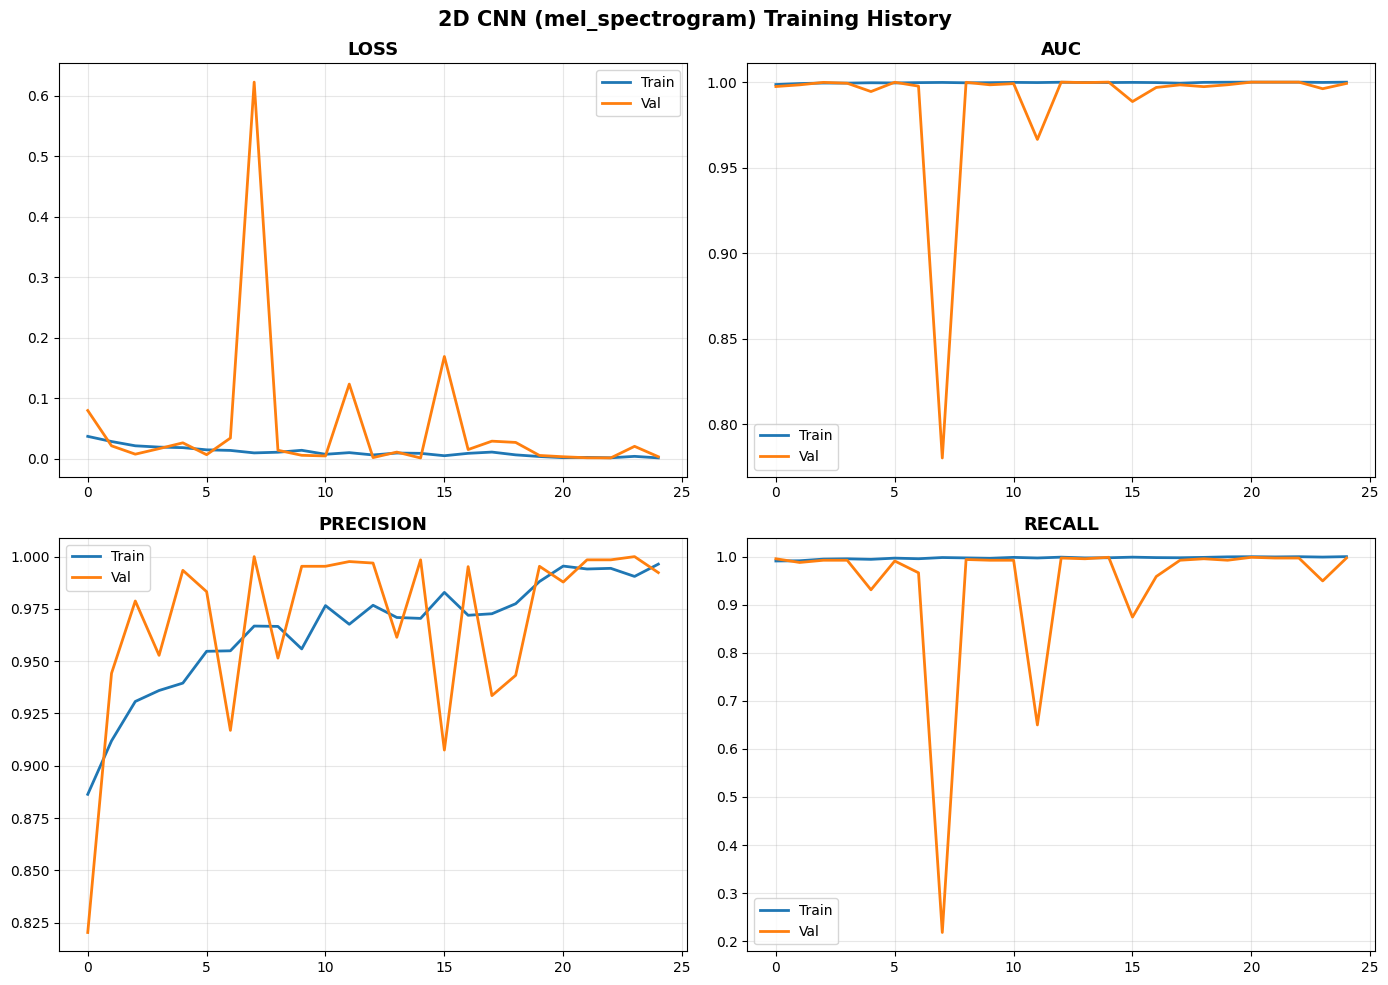

In [8]:
# ============================================================
# CELL 8: Training
# ============================================================

model_path = OUTPUT_DIR / f'2d_cnn_{FEATURE_TYPE}_best.h5'

training_callbacks = [
    callbacks.EarlyStopping(monitor='val_auc', patience=10,
                           restore_best_weights=True, mode='max', verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                               patience=5, min_lr=1e-6, verbose=1),
    callbacks.ModelCheckpoint(str(model_path), monitor='val_auc',
                             save_best_only=True, mode='max', verbose=1),
]

print(f'\n🚀 Training 2D CNN ({FEATURE_TYPE})...\n')

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=training_callbacks,
    verbose=1
)

# --- Plot training history ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, metric in zip(axes.flat, ['loss', 'auc', 'precision', 'recall']):
    ax.plot(history.history[metric], label='Train', linewidth=2)
    ax.plot(history.history[f'val_{metric}'], label='Val', linewidth=2)
    ax.set_title(metric.upper(), fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle(f'2D CNN ({FEATURE_TYPE}) Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'2d_cnn_{FEATURE_TYPE}_history.png', dpi=150)
plt.show()

🔍 Evaluating 2D CNN (mel_spectrogram) on TEST set...

CLASSIFICATION REPORT
              precision    recall  f1-score   support

 Non-Gunshot     0.9998    0.9995    0.9997      6042
     Gunshot     0.9954    0.9985    0.9969       654

    accuracy                         0.9994      6696
   macro avg     0.9976    0.9990    0.9983      6696
weighted avg     0.9994    0.9994    0.9994      6696


KEY METRICS — 2D CNN (mel_spectrogram)
  ROC-AUC : 1.0000
  PR-AUC  : 0.9999
  F2-Score: 0.9979

HEAD-TO-HEAD COMPARISON
Metric              1D CNN     2D CNN     Winner
--------------- ---------- ---------- ----------
ROC-AUC             0.9997     1.0000       2D ✅
PR-AUC              0.9978     0.9999       2D ✅
F2-Score            0.9821     0.9979       2D ✅


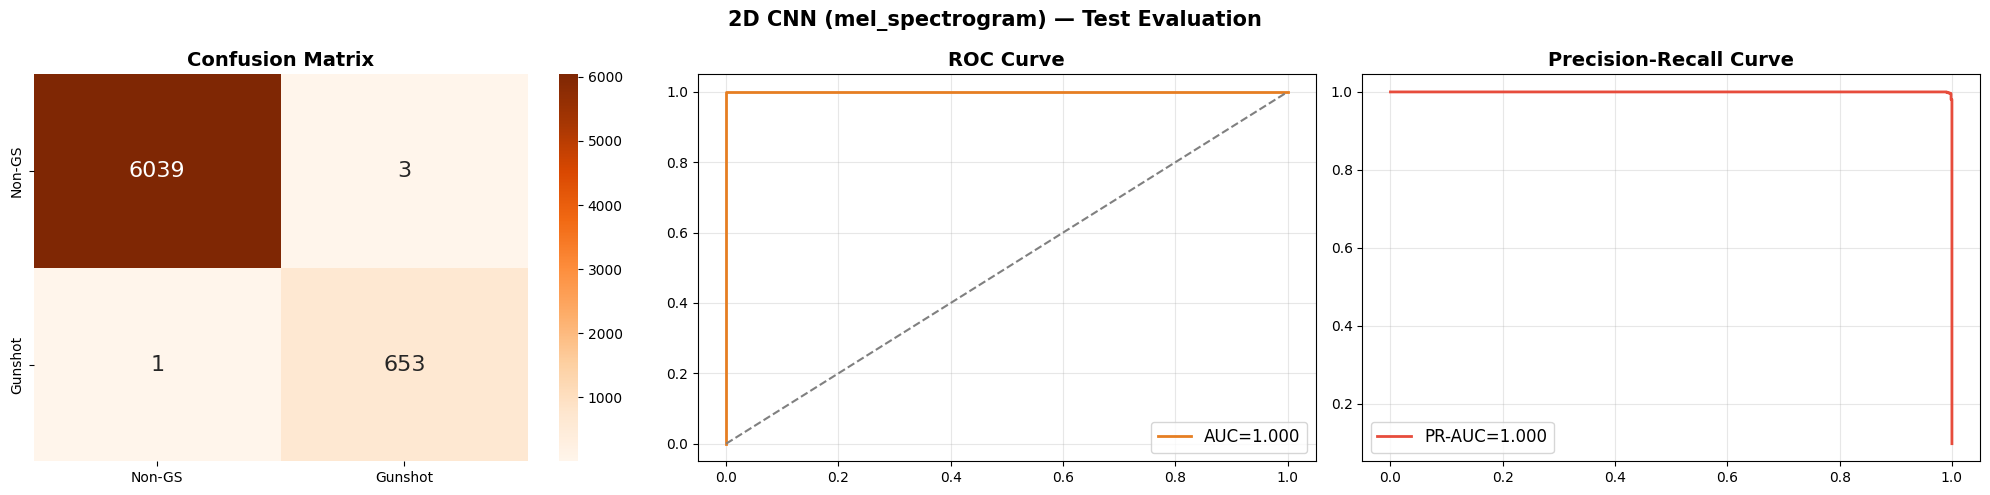

363

In [9]:
# ============================================================
# CELL 9: Evaluation + 1D CNN Comparison
# ============================================================

model = keras.models.load_model(str(model_path))

print(f'🔍 Evaluating 2D CNN ({FEATURE_TYPE}) on TEST set...\n')
y_pred_prob = model.predict(X_test, verbose=0).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

# Classification report
print('=' * 60)
print('CLASSIFICATION REPORT')
print('=' * 60)
print(classification_report(y_test, y_pred,
                            target_names=['Non-Gunshot', 'Gunshot'], digits=4))

# Key metrics
roc_auc = roc_auc_score(y_test, y_pred_prob)
pr_auc = average_precision_score(y_test, y_pred_prob)
f2 = fbeta_score(y_test, y_pred, beta=2)

print(f'\n{"=" * 60}')
print(f'KEY METRICS — 2D CNN ({FEATURE_TYPE})')
print(f'{"=" * 60}')
print(f'  ROC-AUC : {roc_auc:.4f}')
print(f'  PR-AUC  : {pr_auc:.4f}')
print(f'  F2-Score: {f2:.4f}')

# --- Try to load 1D CNN results for comparison ---
cnn1d_results_path = Path.cwd().resolve().parent / '01_1D_CNN' / 'output' / '1d_cnn_results.json'
if cnn1d_results_path.exists():
    cnn1d_results = json.loads(cnn1d_results_path.read_text())
    print(f'\n{"=" * 60}')
    print(f'HEAD-TO-HEAD COMPARISON')
    print(f'{"=" * 60}')
    print(f'{"Metric":<15} {"1D CNN":>10} {"2D CNN":>10} {"Winner":>10}')
    print(f'{"-"*15} {"-"*10} {"-"*10} {"-"*10}')
    for metric_name, key_1d in [('ROC-AUC', 'roc_auc'), ('PR-AUC', 'pr_auc'), ('F2-Score', 'f2_score')]:
        v1 = cnn1d_results.get(key_1d, 0)
        v2 = eval(key_1d.replace('_score', '') if '_score' in key_1d else key_1d)
        winner = '2D ✅' if v2 > v1 else '1D ✅' if v1 > v2 else 'TIE'
        print(f'{metric_name:<15} {v1:>10.4f} {v2:>10.4f} {winner:>10}')
    print(f'{"=" * 60}')
else:
    print(f'\n💡 Run the 1D CNN notebook first to see a comparison.')

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Non-GS', 'Gunshot'],
            yticklabels=['Non-GS', 'Gunshot'],
            ax=axes[0], annot_kws={'size': 16})
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, linewidth=2, color='#e67e22', label=f'AUC={roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], '--', color='gray')
axes[1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

prec, rec, _ = precision_recall_curve(y_test, y_pred_prob)
axes[2].plot(rec, prec, linewidth=2, color='#e74c3c', label=f'PR-AUC={pr_auc:.3f}')
axes[2].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[2].legend(fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'2D CNN ({FEATURE_TYPE}) — Test Evaluation', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'2d_cnn_{FEATURE_TYPE}_evaluation.png', dpi=150)
plt.show()

# Save results
results = {
    'model': f'2D CNN ({FEATURE_TYPE})',
    'feature_type': FEATURE_TYPE,
    'sample_rate': SAMPLE_RATE,
    'roc_auc': float(roc_auc),
    'pr_auc': float(pr_auc),
    'f2_score': float(f2),
    'train_size': len(y_train),
    'test_size': len(y_test),
    'total_params': int(total_params),
    'input_shape': list(input_shape),
    'timestamp': datetime.now().isoformat(),
}
(OUTPUT_DIR / f'2d_cnn_{FEATURE_TYPE}_results.json').write_text(json.dumps(results, indent=2))

False Positives: 3
False Negatives: 1


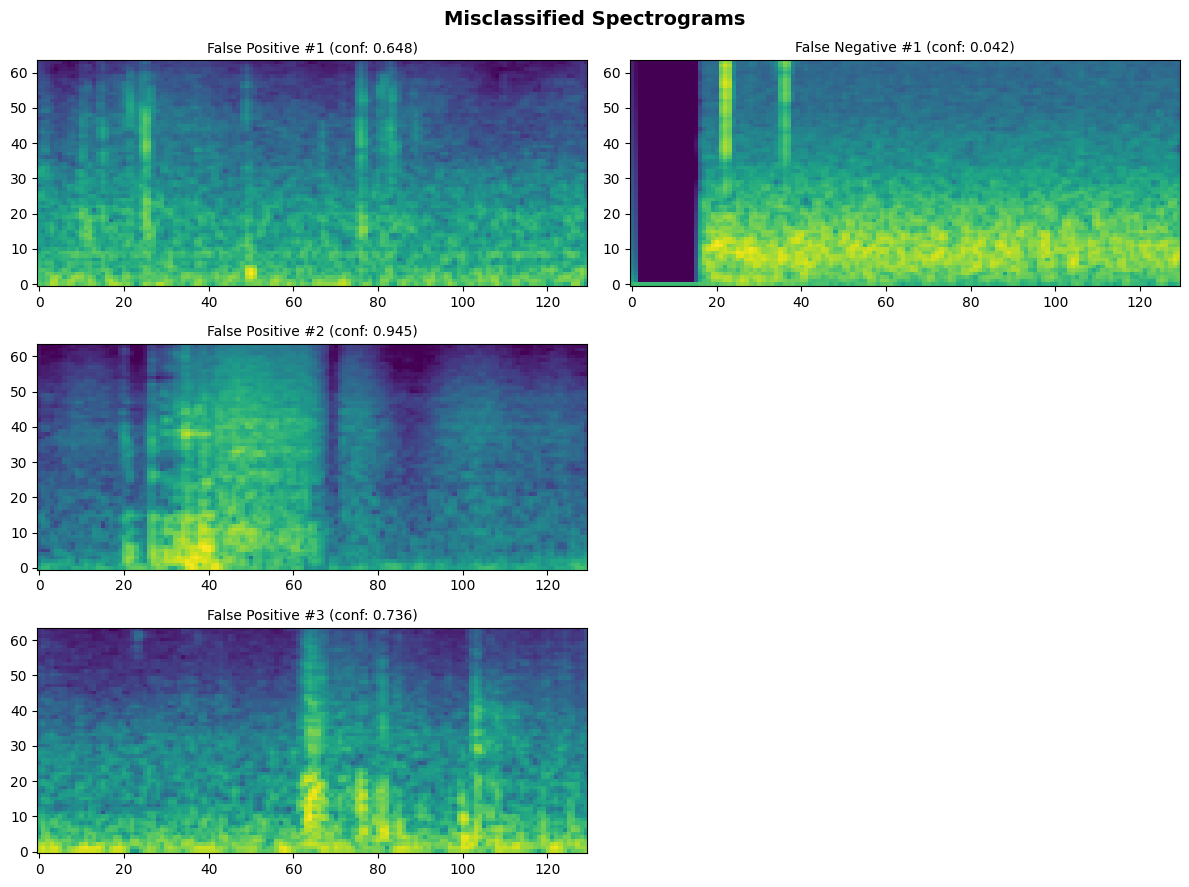

In [10]:
# ============================================================
# CELL 10: Error Analysis
# ============================================================

false_positives = np.where((y_pred == 1) & (y_test == 0))[0]
false_negatives = np.where((y_pred == 0) & (y_test == 1))[0]

print(f'False Positives: {len(false_positives)}')
print(f'False Negatives: {len(false_negatives)}')

n_show = min(3, max(len(false_positives), len(false_negatives)))
if n_show > 0:
    fig, axes = plt.subplots(n_show, 2, figsize=(12, 3 * n_show))
    if n_show == 1:
        axes = axes.reshape(1, -1)
    
    for row in range(n_show):
        for col, (indices, title) in enumerate([
            (false_positives, 'False Positive'),
            (false_negatives, 'False Negative')
        ]):
            if row < len(indices):
                idx = indices[row]
                feat = X_test[idx, :, :, 0]
                axes[row, col].imshow(feat, aspect='auto', origin='lower', cmap='viridis')
                axes[row, col].set_title(f'{title} #{row+1} (conf: {y_pred_prob[idx]:.3f})', fontsize=10)
            else:
                axes[row, col].set_visible(False)
    
    plt.suptitle('Misclassified Spectrograms', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'2d_cnn_{FEATURE_TYPE}_errors.png', dpi=150)
    plt.show()

In [11]:
# ============================================================
# CELL 11: Model Export — H5 + TFLite
# ============================================================

# Keras model
keras_path = OUTPUT_DIR / f'2d_cnn_{FEATURE_TYPE}_detector.h5'
model.save(str(keras_path))
print(f'✅ Keras: {keras_path} ({os.path.getsize(keras_path)/1024:.1f} KB)')

# TFLite float32
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
tflite_path = OUTPUT_DIR / f'2d_cnn_{FEATURE_TYPE}_float32.tflite'
tflite_path.write_bytes(tflite_model)
print(f'✅ TFLite (float32): {tflite_path} ({len(tflite_model)/1024:.1f} KB)')

# TFLite INT8
def representative_dataset():
    for i in range(min(200, len(X_train))):
        yield [X_train[i:i+1]]

converter_q = tf.lite.TFLiteConverter.from_keras_model(model)
converter_q.optimizations = [tf.lite.Optimize.DEFAULT]
converter_q.representative_dataset = representative_dataset
converter_q.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_q.inference_input_type = tf.int8
converter_q.inference_output_type = tf.int8

try:
    tflite_quant = converter_q.convert()
    tflite_q_path = OUTPUT_DIR / f'2d_cnn_{FEATURE_TYPE}_int8.tflite'
    tflite_q_path.write_bytes(tflite_quant)
    print(f'✅ TFLite (INT8): {tflite_q_path} ({len(tflite_quant)/1024:.1f} KB)')
    print(f'   Compression: {len(tflite_model)/len(tflite_quant):.1f}x')
except Exception as e:
    print(f'⚠️ INT8 quantization failed: {e}')

print(f'\n✅ All outputs in: {OUTPUT_DIR}')

✅ Keras: C:\Users\aadit\Desktop\Shoot_Catcher\02_2D_CNN\output\2d_cnn_mel_spectrogram_detector.h5 (1045.8 KB)
INFO:tensorflow:Assets written to: C:\Users\aadit\AppData\Local\Temp\tmp0x38kq16\assets


INFO:tensorflow:Assets written to: C:\Users\aadit\AppData\Local\Temp\tmp0x38kq16\assets


: 